# EdgeEngine AWARE — training and evaluating RL policies

This notebook answers one question: **does a learned policy beat the interpretable
rule-based controller, and where?** It is the first step of the pipeline
*simulation → training → validation → export → deployment*.

What it does:

1. defines the **evaluation protocol** — six named scenarios, held-out seeds, one metric table;
2. measures the **baselines** (rule-based, periodic duty cycles, random) on every scenario;
3. trains **PPO** (on the native `MultiDiscrete([3, 2])` action space) and **DQN** (on the
   flat 6-action encoding) on a *mixture* of the six scenarios with domain randomisation;
4. plots **learning curves** against the baselines;
5. runs the **full comparison** on all scenarios and shows where the learned policies win or lose;
6. looks at **what the agent learned** (actions vs. battery, priority, time of day);
7. **exports** the PPO actor as a `PolicyBundle` and checks that a numpy-only forward pass —
   the same arithmetic a microcontroller would run — reproduces the SB3 actions exactly.

> **Runtime.** With the default budget (`BUDGET = "default"`: 2 M PPO steps, 1 M DQN steps,
> 20 evaluation seeds) the notebook takes roughly 30–40 minutes on a laptop CPU (measured:
> 27 min on 2 cloud CPU threads). Set
> `BUDGET = "quick"` for a 3-minute smoke test (the curves will look undertrained) or
> `"paper"` for a longer, lower-variance run. Trained models are saved under `examples/rl_runs/`
> and reused on the next run of the same budget unless `EEA_RETRAIN=1` is set, so the analysis
> cells can be re-run in a few minutes.

## 0. Setup

Requires the RL extras: `pip install -e ".[rl]"` (Stable-Baselines3 ≥ 2.0 and PyTorch, CPU is fine).

In [1]:
import os, sys, time, pathlib, warnings
ROOT = pathlib.Path.cwd().resolve()
if not (ROOT / "edgeengine_aware").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=UserWarning)

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback

import edgeengine_aware as ea
from edgeengine_aware.policies import RuleBasedPolicy, RandomPolicy, PeriodicPolicy, run_episode
from edgeengine_aware.scenarios import SCENARIOS, get_scenario
from edgeengine_aware.rl import make_env, make_env_fn, SB3Policy, evaluate, summarize, export_sb3_mlp, NumpyMLPPolicy
from edgeengine_aware.deployment import export_policy
from edgeengine_aware.observation import NodeProfile

torch.set_num_threads(max(1, os.cpu_count() // 2))
print("EdgeEngine AWARE", ea.__version__, "| torch", torch.__version__, "| threads", torch.get_num_threads())

EdgeEngine AWARE 0.1.0 | torch 2.14.0+cu130 | threads 1


### Budget

One switch controls training length and the number of evaluation seeds. Evaluation seeds
start at 1000 so they never overlap the training seeds (0–7).

In [2]:
BUDGET = os.environ.get("EEA_BUDGET", "default")      # "quick" | "default" | "paper"
BUDGETS = {
    "quick":   dict(ppo_steps=100_000,   dqn_steps=60_000,    eval_seeds=4,  n_envs=8, eval_every=25_000,  eval_episodes=6),
    "default": dict(ppo_steps=2_000_000, dqn_steps=1_000_000, eval_seeds=20, n_envs=8, eval_every=100_000, eval_episodes=12),
    "paper":   dict(ppo_steps=5_000_000, dqn_steps=2_000_000, eval_seeds=50, n_envs=8, eval_every=100_000, eval_episodes=24),
}
B = BUDGETS[BUDGET]
EVAL_SEEDS = range(1000, 1000 + B["eval_seeds"])
OUT = ROOT / "examples" / "rl_runs"; OUT.mkdir(exist_ok=True)
FORCE_RETRAIN = os.environ.get("EEA_RETRAIN", "0") == "1"   # False: reuse a saved model of this budget if present
print(f"budget = {BUDGET}: {B}")

budget = default: {'ppo_steps': 2000000, 'dqn_steps': 1000000, 'eval_seeds': 20, 'n_envs': 8, 'eval_every': 100000, 'eval_episodes': 12}


### Plot style

A small, fixed categorical palette (one colour per *policy*, never re-assigned when a policy is
missing from a chart), thin marks, recessive grid, direct labels where they help.

In [3]:
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
POLICY_ORDER = ["PPO", "DQN", "rule-based", "periodic 1h", "periodic 3h", "random"]
COLOR = {p: PALETTE[i] for i, p in enumerate(POLICY_ORDER)}   # colour follows the policy, not its rank
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK, "ytick.labelcolor": INK,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "legend.frameon": False,
})

def tidy(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, loc="left")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.tick_params(length=0)
    return ax

## 1. The evaluation protocol

Six scenarios (`edgeengine_aware.scenarios`). `default` is the nominal configuration; each of
the others stresses one aspect of the problem so that adaptivity has somewhere to show up.
All metrics come from `EpisodeMetrics`, i.e. the same quantities a deployed node and its
application would log.

In [4]:
print(f"{'scenario':24s} {'harvest':>9s} {'battery':>8s} {'p(deliv)':>9s} {'ET/day':>7s} {'requests/day':>13s}")
for name in SCENARIOS:
    c = get_scenario(name)
    print(f"{name:24s} {c.harvesting.max_power_w*1e3*c.harvesting.efficiency*c.harvesting.clearness_mean:7.2f} mW {c.storage.capacity_j:6.0f} J {c.communication.base_success_prob:9.2f} {c.agriculture.et_rate_per_day:7.2f} {c.application.request_rate_per_day:13.1f}")

scenario                   harvest  battery  p(deliv)  ET/day  requests/day
default                     2.10 mW    300 J      0.90    0.06           0.2
cloudy_week                 1.05 mW    300 J      0.90    0.06           0.2
tiny_battery                2.10 mW    150 J      0.90    0.06           0.2
lossy_link                  2.10 mW    300 J      0.55    0.06           0.2
drought                     2.10 mW    300 J      0.90    0.12           0.2
demanding_application       2.10 mW    300 J      0.90    0.06           1.5


## 2. Baselines on every scenario

Policies are passed as factories so that stateful ones start clean at each episode.

In [5]:
BASELINES = {
    "rule-based":  RuleBasedPolicy,
    "periodic 1h": lambda: PeriodicPolicy(period_steps=4, sensing_level=2),
    "periodic 3h": lambda: PeriodicPolicy(period_steps=12, sensing_level=2),
    "random":      lambda: RandomPolicy(seed=0),
}
t0 = time.time()
baseline_rows = evaluate(BASELINES, SCENARIOS, seeds=EVAL_SEEDS)
print(f"{len(baseline_rows)} episodes in {time.time()-t0:.0f} s")

def print_table(rows, metric="reward", fmt="{:7.1f}"):
    summ = summarize(rows, metric)
    policies = [p for p in POLICY_ORDER if any(p in d for d in summ.values())]
    print(f"{metric:>24s} " + " ".join(f"{p:>14s}" for p in policies))
    for scen, d in summ.items():
        print(f"{scen:>24s} " + " ".join((fmt.format(d[p][0]) + " ±" + f"{d[p][1]:4.0f}") if p in d else " " * 14 for p in policies))

print_table(baseline_rows, "reward")
print(); print_table(baseline_rows, "min_soc", "{:7.2f}")

480 episodes in 53 s
                  reward     rule-based    periodic 1h    periodic 3h         random
                 default    83.0 ±  27    81.0 ±  28    77.3 ±  25     1.2 ±  69
             cloudy_week    54.8 ±  25   -59.8 ± 128    76.3 ±  25  -405.9 ± 144
            tiny_battery    82.1 ±  27    77.4 ±  28    75.9 ±  25  -123.6 ± 138
              lossy_link    73.3 ±  24    69.4 ±  25    56.7 ±  20    -3.8 ±  70
                 drought   122.7 ±  17   131.3 ±   8   112.1 ±   8    42.1 ±  72
   demanding_application    80.0 ±  27    79.5 ±  28    72.4 ±  26    -0.3 ±  70

                 min_soc     rule-based    periodic 1h    periodic 3h         random
                 default    0.44 ±   0    0.42 ±   0    0.47 ±   0    0.13 ±   0
             cloudy_week    0.20 ±   0    0.06 ±   0    0.30 ±   0    0.00 ±   0
            tiny_battery    0.39 ±   0    0.34 ±   0    0.45 ±   0    0.02 ±   0
              lossy_link    0.40 ±   0    0.42 ±   0    0.47 ±   0    0.13 ±   

The periodic duty cycle is a strong baseline on the nominal scenario and collapses
where the energy budget shrinks (`cloudy_week`, `tiny_battery`): it has no notion of battery.
The rule-based controller survives everywhere but pays for it with staler information.
This is the gap a learned policy is supposed to close.

## 3. Training

**Training distribution.** Each training episode draws one of the six scenarios at random
(`MixedScenarioEnv`) and, inside it, applies **domain randomisation** (sensor noise, energy
costs, link quality, solar intensity, cloudiness, battery capacity and MCU consumption are
resampled at every reset). A policy trained only on the nominal `default` scenario converges
to a duty cycle and breaks on the cloudy week — see the note at the end; training on the
mixture is what forces energy awareness.

**Evaluation.** Always greedy, *without* randomisation, on the nominal scenarios and on
held-out seeds. An `EvalCallback` evaluates the greedy policy on the training distribution
every `eval_every` steps, keeps the **best checkpoint** and gives us clean learning curves.

In [6]:
TRAIN_SCENARIOS = list(SCENARIOS)      # the mixture the agents train on

def make_vec(n_envs, flat_actions):
    return DummyVecEnv([make_env_fn(TRAIN_SCENARIOS, randomize=True, flat_actions=flat_actions, seed=i) for i in range(n_envs)])

def make_eval_callback(flat_actions, log_dir):
    log_dir = pathlib.Path(log_dir); log_dir.mkdir(parents=True, exist_ok=True)
    eval_env = Monitor(make_env(TRAIN_SCENARIOS, randomize=True, flat_actions=flat_actions, seed=10_000))
    return EvalCallback(eval_env, n_eval_episodes=B["eval_episodes"], eval_freq=max(1, B["eval_every"] // B["n_envs"]),
                        best_model_save_path=str(log_dir), log_path=str(log_dir), deterministic=True, verbose=0)

def load_eval_curve(log_dir):
    data = np.load(pathlib.Path(log_dir) / "evaluations.npz")
    return data["timesteps"], data["results"].mean(axis=1), data["results"].std(axis=1)

### 3a. PPO on the native `MultiDiscrete` action space

Two independent categorical heads (3 sensing levels × 2 transmit choices). A small
`64×64 tanh` network is plenty for 17 inputs and keeps the export trivially embeddable.
`gamma = 0.99` gives an effective horizon of ~100 steps = 25 h, which covers a full
day/night cycle of harvesting.

In [7]:
ppo_log = OUT / f"ppo_{BUDGET}"
if FORCE_RETRAIN or not (ppo_log / "best_model.zip").exists():
    ppo = PPO("MlpPolicy", make_vec(B["n_envs"], flat_actions=False), n_steps=256, batch_size=256, n_epochs=10,
              gamma=0.99, gae_lambda=0.95, learning_rate=3e-4, ent_coef=0.01, clip_range=0.2,
              policy_kwargs=dict(net_arch=[64, 64]), seed=0, device="cpu", verbose=0)
    t0 = time.time()
    ppo.learn(total_timesteps=B["ppo_steps"], callback=make_eval_callback(False, ppo_log), progress_bar=False)
    print(f"PPO: {B['ppo_steps']:,} steps in {time.time()-t0:.0f} s")
    ppo.save(OUT / f"ppo_{BUDGET}_last.zip")
else:
    print(f"PPO: reusing {ppo_log / 'best_model.zip'} (set EEA_RETRAIN=1 to retrain)")
ppo = PPO.load(ppo_log / "best_model.zip", device="cpu")      # the best greedy checkpoint

PPO: reusing /home/claude/edgeengine_aware/examples/rl_runs/ppo_default/best_model.zip (set EEA_RETRAIN=1 to retrain)


### 3b. DQN on the flat 6-action encoding

`FlatActionWrapper` maps `Discrete(6)` back to `(sensing_level, transmit)` with
`flat = sensing_level * 2 + transmit`. DQN is included because a Q-table or a Q-network with
six outputs is the most natural thing to put on a microcontroller.

In [8]:
dqn_log = OUT / f"dqn_{BUDGET}"
if FORCE_RETRAIN or not (dqn_log / "best_model.zip").exists():
    dqn = DQN("MlpPolicy", make_vec(B["n_envs"], flat_actions=True), learning_rate=5e-4, buffer_size=200_000,
              learning_starts=20_000, batch_size=256, gamma=0.99, train_freq=4, gradient_steps=1,
              target_update_interval=5_000, exploration_fraction=0.3, exploration_final_eps=0.05,
              policy_kwargs=dict(net_arch=[64, 64]), seed=0, device="cpu", verbose=0)
    t0 = time.time()
    dqn.learn(total_timesteps=B["dqn_steps"], callback=make_eval_callback(True, dqn_log), progress_bar=False)
    print(f"DQN: {B['dqn_steps']:,} steps in {time.time()-t0:.0f} s")
    dqn.save(OUT / f"dqn_{BUDGET}_last.zip")
else:
    print(f"DQN: reusing {dqn_log / 'best_model.zip'} (set EEA_RETRAIN=1 to retrain)")
dqn = DQN.load(dqn_log / "best_model.zip", device="cpu")

DQN: reusing /home/claude/edgeengine_aware/examples/rl_runs/dqn_default/best_model.zip (set EEA_RETRAIN=1 to retrain)


## 4. Learning curves

Greedy episode reward on the training distribution (mixture of scenarios, randomised
physics) measured by the evaluation callback during training, against the two reference
policies on the same distribution. The shaded band is ± one standard deviation across the
evaluation episodes — the mixture is wide, so the band is wide too.

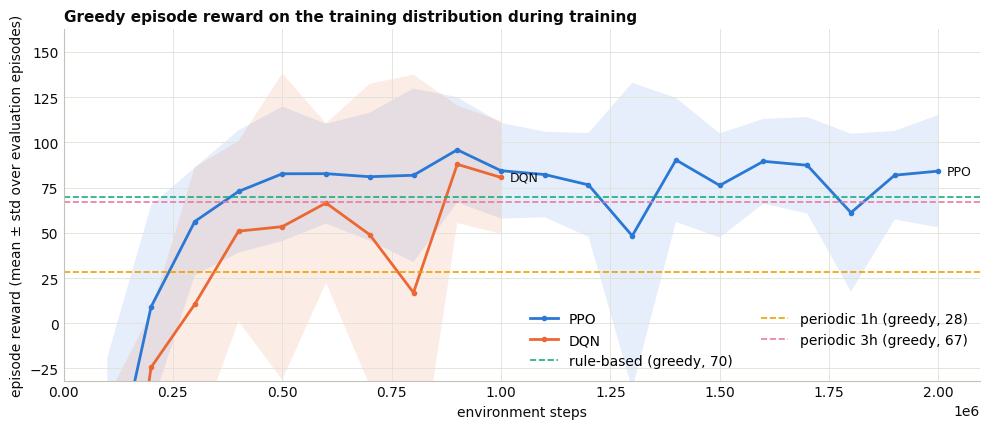

In [9]:
ref_rows = evaluate({"rule-based": RuleBasedPolicy, "periodic 1h": lambda: PeriodicPolicy(4, 2), "periodic 3h": lambda: PeriodicPolicy(12, 2)},
                    ["mixed"], seeds=range(10_000, 10_000 + 4 * B["eval_episodes"]), randomize=True)
ref = summarize(ref_rows)["mixed"]

fig, ax = plt.subplots(figsize=(10, 4.4))
for name, log_dir in [("PPO", ppo_log), ("DQN", dqn_log)]:
    x, y, sd = load_eval_curve(log_dir)
    ax.plot(x, y, color=COLOR[name], lw=2, marker="o", ms=3, label=name)
    ax.fill_between(x, y - sd, y + sd, color=COLOR[name], alpha=0.12, lw=0)
    ax.annotate(name, (x[-1], y[-1]), xytext=(6, 0), textcoords="offset points", va="center", color=INK, fontsize=9)
for name in ("rule-based", "periodic 1h", "periodic 3h"):
    ax.axhline(ref[name][0], color=COLOR[name], lw=1.2, ls="--", label=f"{name} (greedy, {ref[name][0]:.0f})")
lo = min(ref[n][0] for n in ref) - 60
ax.set_ylim(bottom=max(lo, -150)); ax.set_xlim(left=0); ax.margins(x=0.08)
ax.legend(loc="lower right", ncol=2)
tidy(ax, "Greedy episode reward on the training distribution during training", "environment steps", "episode reward (mean ± std over evaluation episodes)")
plt.tight_layout(); plt.show()

## 5. Full comparison on all scenarios

Greedy (deterministic) policies, nominal (non-randomised) scenarios, held-out seeds — the same
protocol as for the baselines, including the seeds, so differences are paired. The learned
agents have seen these scenario *types* during training, but never these seeds nor the
nominal parameter values, which sit inside the randomisation ranges.

In [10]:
LEARNED = {"PPO": lambda: SB3Policy(ppo), "DQN": lambda: SB3Policy(dqn, flat_actions=True)}
t0 = time.time()
learned_rows = evaluate(LEARNED, SCENARIOS, seeds=EVAL_SEEDS)
print(f"{len(learned_rows)} episodes in {time.time()-t0:.0f} s")
ALL_ROWS = learned_rows + baseline_rows

print_table(ALL_ROWS, "reward"); print()
print_table(ALL_ROWS, "utility"); print()
print_table(ALL_ROWS, "min_soc", "{:7.2f}"); print()
print_table(ALL_ROWS, "aoi_h", "{:7.2f}")

240 episodes in 77 s
                  reward            PPO            DQN     rule-based    periodic 1h    periodic 3h         random
                 default    80.7 ±  28    71.6 ±  32    83.0 ±  27    81.0 ±  28    77.3 ±  25     1.2 ±  69
             cloudy_week    69.7 ±  33    63.8 ±  45    54.8 ±  25   -59.8 ± 128    76.3 ±  25  -405.9 ± 144
            tiny_battery    80.0 ±  28    69.5 ±  32    82.1 ±  27    77.4 ±  28    75.9 ±  25  -123.6 ± 138
              lossy_link    73.5 ±  26    64.2 ±  29    73.3 ±  24    69.4 ±  25    56.7 ±  20    -3.8 ±  70
                 drought   127.2 ±   7   118.6 ±   8   122.7 ±  17   131.3 ±   8   112.1 ±   8    42.1 ±  72
   demanding_application    78.6 ±  28    69.0 ±  32    80.0 ±  27    79.5 ±  28    72.4 ±  26    -0.3 ±  70

                 utility            PPO            DQN     rule-based    periodic 1h    periodic 3h         random
                 default   104.9 ±  29    95.7 ±  33   107.2 ±  29   107.3 ±  29   101.3 ±  28

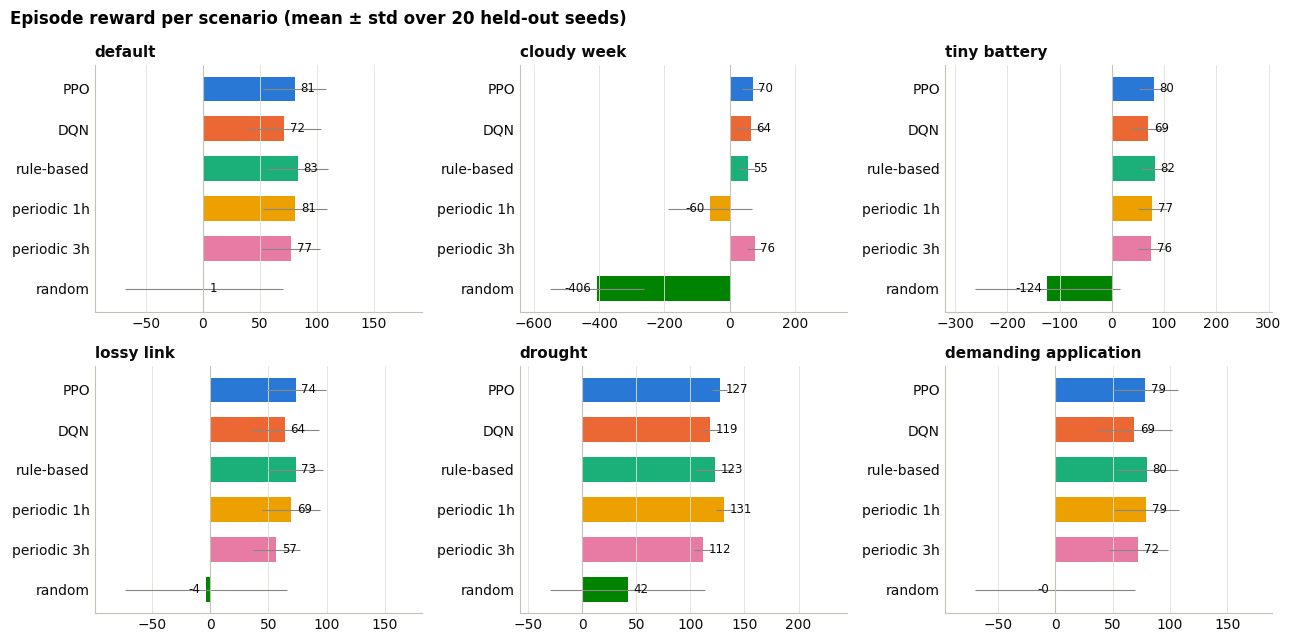

In [11]:
# One panel per scenario, one bar per policy (fixed colour), std as a thin error bar.
summ = summarize(ALL_ROWS, "reward")
scen_names = list(SCENARIOS)
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=False)
for ax, scen in zip(axes.ravel(), scen_names):
    d = summ[scen]
    pols = [p for p in POLICY_ORDER if p in d]
    means = [d[p][0] for p in pols]; stds = [d[p][1] for p in pols]
    y = np.arange(len(pols))[::-1]
    ax.barh(y, means, xerr=stds, color=[COLOR[p] for p in pols], height=0.62, error_kw=dict(lw=0.8, ecolor=MUTED, capsize=0))
    ax.set_yticks(y); ax.set_yticklabels(pols)
    for yi, m in zip(y, means):
        ax.annotate(f"{m:.0f}", (m, yi), xytext=(4 if m >= 0 else -4, 0), textcoords="offset points", ha="left" if m >= 0 else "right", va="center", fontsize=8.5, color=INK)
    ax.axvline(0, color="#c3c2b7", lw=0.8)
    ax.grid(axis="y", visible=False)
    tidy(ax, scen.replace("_", " "))
    lo = min(0, min(means) - max(stds)); hi = max(means) + max(stds)
    ax.set_xlim(lo - 0.12 * (hi - lo), hi + 0.18 * (hi - lo))
fig.suptitle(f"Episode reward per scenario (mean ± std over {B['eval_seeds']} held-out seeds)", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

### Reward relative to the rule-based controller

Same data, read as "how much better or worse than the interpretable baseline" — a diverging
scale around zero, paired by seed. Positive (blue) means the policy beats the rule-based one.

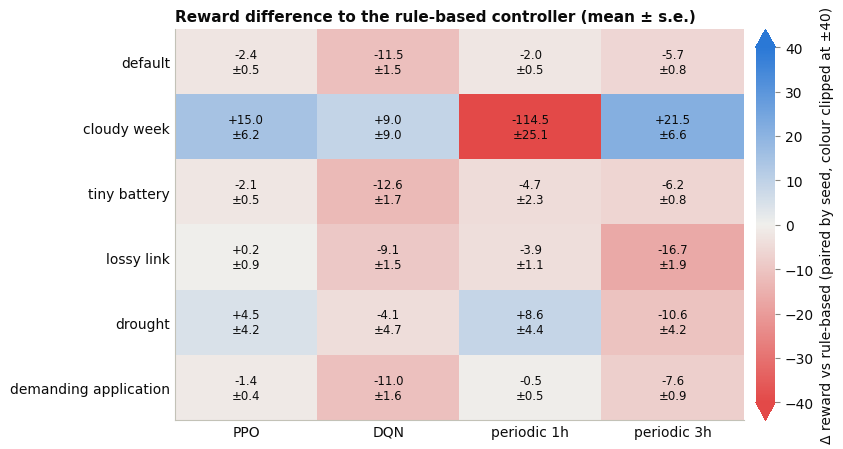

In [12]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
def paired_delta(rows, ref="rule-based", metric="reward"):
    by = {}
    for r in rows:
        by.setdefault((r.scenario, r.policy), {})[r.seed] = getattr(r, metric)
    out = {}
    for (scen, pol), d in by.items():
        if pol == ref: continue
        refd = by[(scen, ref)]
        deltas = [d[s] - refd[s] for s in d if s in refd]
        out.setdefault(scen, {})[pol] = (np.mean(deltas), np.std(deltas) / np.sqrt(len(deltas)))
    return out

delta = paired_delta(ALL_ROWS)
pols = [p for p in POLICY_ORDER if p != "rule-based" and p != "random"]
M = np.array([[delta[s][p][0] for p in pols] for s in scen_names])
SE = np.array([[delta[s][p][1] for p in pols] for s in scen_names])
lim = min(np.max(np.abs(M)), 40.0)          # colour saturates at ±40 so one collapse does not wash out the rest
cmap = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
fig, ax = plt.subplots(figsize=(8.5, 4.6))
im = ax.imshow(M, cmap=cmap, norm=TwoSlopeNorm(vcenter=0, vmin=-lim, vmax=lim), aspect="auto")
ax.set_xticks(range(len(pols))); ax.set_xticklabels(pols)
ax.set_yticks(range(len(scen_names))); ax.set_yticklabels([s.replace("_", " ") for s in scen_names])
ax.grid(False)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i,j]:+.1f}\n±{SE[i,j]:.1f}", ha="center", va="center", fontsize=8.5, color=INK)
cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02, extend="both"); cb.set_label("Δ reward vs rule-based (paired by seed, colour clipped at ±40)"); cb.outline.set_visible(False)
tidy(ax, "Reward difference to the rule-based controller (mean ± s.e.)")
plt.tight_layout(); plt.show()

### Where does the reward come from?

The decomposition on the two most informative scenarios: the training distribution and the
cloudy week. Bars to the right are utility earned, bars to the left are costs and penalties.

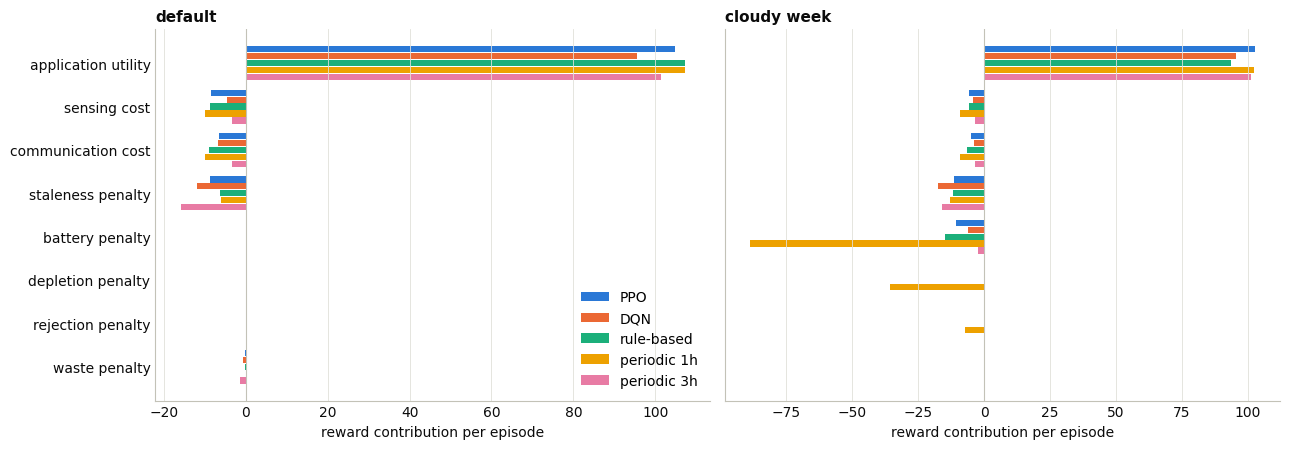

In [13]:
COMP = ["application_utility", "sensing_cost", "communication_cost", "staleness_penalty", "battery_penalty", "depletion_penalty", "rejection_penalty", "waste_penalty"]
def components_by_policy(rows, scenario):
    out = {}
    for r in rows:
        if r.scenario != scenario: continue
        out.setdefault(r.policy, []).append([r.components.get(c, 0.0) for c in COMP])
    return {p: np.mean(v, axis=0) for p, v in out.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, scen in zip(axes, ["default", "cloudy_week"]):
    comp = components_by_policy(ALL_ROWS, scen)
    pols = [p for p in POLICY_ORDER if p in comp and p != "random"]
    y = np.arange(len(COMP))[::-1]; h = 0.8 / len(pols)
    for k, p in enumerate(pols):
        vals = comp[p].copy(); vals[1:] = -vals[1:]      # costs drawn to the left
        ax.barh(y + (len(pols) - 1 - k) * h - 0.4 + h / 2, vals, height=h * 0.9, color=COLOR[p], label=p)
    ax.set_yticks(y); ax.set_yticklabels([c.replace("_", " ") for c in COMP])
    ax.axvline(0, color="#c3c2b7", lw=0.8); ax.grid(axis="y", visible=False)
    tidy(ax, scen.replace("_", " "), "reward contribution per episode")
axes[0].legend(loc="lower right")
plt.tight_layout(); plt.show()

## 6. What did the agent learn?

Numbers say *whether* PPO is better; the next plots say *how it behaves*. First a full episode
on the cloudy scenario — the one where a fixed duty cycle fails.

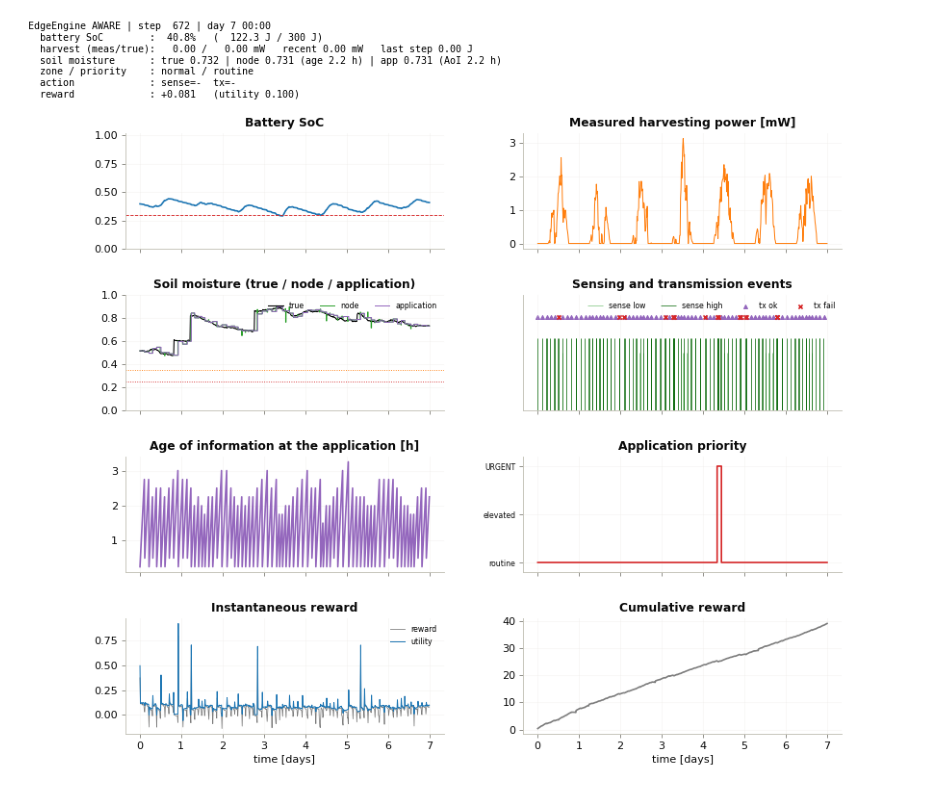

total_reward               : 38.97
total_application_utility  : 59.45
total_harvested_energy_j   : 248.1 J
total_consumed_energy_j    : 245.9 J
baseline_energy_j          : 121.0 J
sensing_energy_j           : 72.7 J
communication_energy_j     : 52.2 J
wasted_harvest_energy_j    : 0.0 J
n_sensing                  : 132
n_high_quality_sensing     : 119
n_transmissions            : 87
n_successful_transmissions : 72
delivery_ratio             : 0.83
n_rejected_actions         : 0
average_battery_soc        : 0.370
min_battery_soc            : 0.289
fraction_low_battery       : 0.030
battery_depletion_events   : 0
average_aoi_h              : 1.37 h
max_aoi_h                  : 3.25 h


In [14]:
env_c = make_env("cloudy_week", render_mode="rgb_array")
res = run_episode(env_c, SB3Policy(ppo), seed=1003)
frame = env_c.render()
fig, ax = plt.subplots(figsize=(12, 10)); ax.imshow(frame); ax.axis("off"); plt.show()
print(env_c.unwrapped.metrics.summary())

### Actions against battery, harvesting and priority

For each policy, the fraction of steps with a high-quality sample and with a transmission, as a
function of the battery state of charge (left) and of the application priority (right),
pooled over the evaluation episodes of the `cloudy_week` scenario.

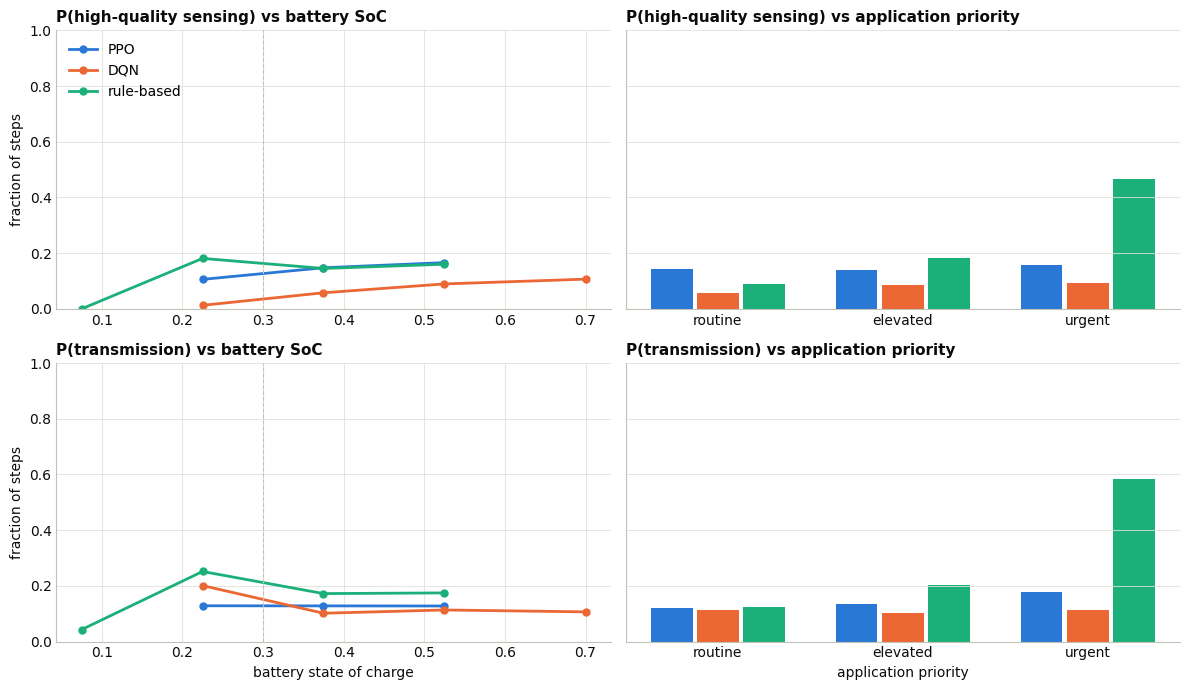

In [15]:
def action_profile(policy_factory, scenario, seeds):
    env = make_env(scenario)
    soc, prio, hq, tx = [], [], [], []
    i_soc = env.unwrapped.obs_builder.index("battery_soc"); i_pr = env.unwrapped.obs_builder.index("app_priority")
    for s in seeds:
        obs, _ = env.reset(seed=s); pol = policy_factory(); pol.reset(); done = False
        while not done:
            a = pol.act(obs)
            soc.append(obs[i_soc]); prio.append(int(round(obs[i_pr] * 2))); hq.append(int(a[0] == 2)); tx.append(int(a[1] == 1))
            obs, _, term, trunc, info = env.step(a); done = term or trunc
    return np.array(soc), np.array(prio), np.array(hq), np.array(tx)

profiles = {p: action_profile(f, "cloudy_week", list(EVAL_SEEDS)[:8]) for p, f in {**LEARNED, "rule-based": RuleBasedPolicy}.items()}
soc_bins = np.array([0, 0.15, 0.3, 0.45, 0.6, 0.8, 1.0])
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey="row")
for row, (what, idx) in enumerate([("high-quality sensing", 2), ("transmission", 3)]):
    ax = axes[row, 0]
    for p, prof in profiles.items():
        soc = prof[0]; y = prof[idx]
        centers, rates = [], []
        for lo, hi in zip(soc_bins[:-1], soc_bins[1:]):
            m = (soc >= lo) & (soc < hi)
            if m.sum() >= 20: centers.append((lo + hi) / 2); rates.append(y[m].mean())
        ax.plot(centers, rates, marker="o", ms=5, lw=2, color=COLOR[p], label=p)
    ax.axvline(0.3, color="#c3c2b7", lw=0.8, ls="--"); ax.set_ylim(0, 1)
    tidy(ax, f"P({what}) vs battery SoC", "battery state of charge" if row else None, "fraction of steps")
    ax = axes[row, 1]
    w = 0.25
    for k, (p, prof) in enumerate(profiles.items()):
        rates = [prof[idx][prof[1] == lvl].mean() if (prof[1] == lvl).any() else np.nan for lvl in (0, 1, 2)]
        ax.bar(np.arange(3) + (k - 1) * w, rates, width=w * 0.9, color=COLOR[p], label=p)
    ax.set_xticks(range(3)); ax.set_xticklabels(["routine", "elevated", "urgent"]); ax.grid(axis="x", visible=False)
    tidy(ax, f"P({what}) vs application priority", "application priority" if row else None)
axes[0, 0].legend(loc="upper left")
plt.tight_layout(); plt.show()

Things to look for: a learned policy that has understood the problem transmits **less when the
battery is low and more when the priority is high**, and prefers **cheap checks** between
reports. If PPO instead shows flat lines, it has collapsed to a duty cycle — the reward is then
too flat to teach adaptivity and the scenarios or the weights need revisiting.

## 7. Export: from SB3 to a deployable bundle

The PPO actor is a `17 → 64 → 64 → 5` MLP (`tanh`, two categorical heads of 3 and 2 logits).
`export_sb3_mlp` extracts its weights as plain lists; `export_policy` wraps them with the
observation order, the normalisation constants and the action encoding. `NumpyMLPPolicy` then
runs the bundle with numpy only — the same arithmetic a C port would do — and we check that it
reproduces the SB3 actions **on every observation** of several episodes.

In [16]:
profile = NodeProfile.from_config(get_scenario("default"))
weights = export_sb3_mlp(ppo)
bundle = export_policy(SB3Policy(ppo), profile, policy_type="mlp_ppo", model=weights, notes=f"PPO {B['ppo_steps']:,} steps, domain randomisation on")
path = bundle.save(OUT / f"ppo_{BUDGET}_bundle.json")
n_params = sum(np.size(l["W"]) + np.size(l["b"]) for l in weights["layers"])
print(f"bundle saved to {path.name}: {n_params} parameters, layers {[np.array(l['W']).shape for l in weights['layers']]}")

runtime = NumpyMLPPolicy(weights)
sb3 = SB3Policy(ppo)
env = make_env("default")
agree = total = 0
for s in list(EVAL_SEEDS)[:5]:
    obs, _ = env.reset(seed=s); done = False
    while not done:
        a_ref = sb3.act(obs); a_np = runtime.act(obs)
        agree += int(np.array_equal(a_ref, a_np)); total += 1
        obs, _, term, trunc, _ = env.step(a_ref); done = term or trunc
print(f"numpy runtime reproduces SB3 actions on {agree}/{total} observations ({100*agree/total:.2f} %)")

# and the numpy runtime scores the same as the SB3 model
rows_np = evaluate({"PPO (numpy runtime)": lambda: NumpyMLPPolicy(weights), "PPO": lambda: SB3Policy(ppo)}, ["default"], seeds=list(EVAL_SEEDS)[:5])
for p, (m, sd) in summarize(rows_np)["default"].items(): print(f"{p:22s} {m:7.2f} ± {sd:4.1f}")

bundle saved to ppo_default_bundle.json: 5637 parameters, layers [(64, 17), (64, 64), (5, 64)]


numpy runtime reproduces SB3 actions on 3360/3360 observations (100.00 %)


PPO (numpy runtime)      75.21 ± 32.1
PPO                      75.21 ± 32.1


The bundle is what travels to the device: observation order and normalisation, action encoding,
the ~5 k parameters and metadata. Ports to TensorFlow Lite Micro, CMSIS-NN or a hand-written
dense loop start from this file (see `docs/deployment.md`).

### Why train on the mixture?

The first version of this notebook trained PPO on the nominal `default` scenario only
(with domain randomisation). Its learning curve reached the rule-based level after ~0.5 M
steps and then went flat: on a sunny week the reward surface is deliberately flat between
"report every hour" and "report every three hours", so the agent settled on a duty cycle
with a modest battery guard. Evaluated on `cloudy_week` it collapsed (−1 ± 109 reward over
20 seeds) — it had never experienced a week in which hourly reporting is unaffordable.
Putting the stress scenarios into the training distribution is the cheapest fix and is
also the realistic one: a deployed node will see cloudy weeks.

## 8. Reading the results

Use the tables and the Δ-heatmap above to answer, scenario by scenario:

1. **Does the learned policy beat the rule-based controller on the nominal `default`
   scenario?** On a sunny week the reward is deliberately flat between sensible duty cycles,
   so a small margin (or parity) here is expected; a large deficit means under-training.
2. **Does it win where adaptivity matters?** `cloudy_week` and `tiny_battery` test energy
   awareness, `drought` and `demanding_application` test application awareness, `lossy_link`
   tests retransmission behaviour. A robust policy should not fall below the rule-based one
   anywhere and should beat the fixed duty cycles clearly on the energy-limited scenarios.
3. **Is the margin explained by the components?** A win obtained by cutting staleness while
   keeping the battery penalty at zero is the intended behaviour; a win obtained by draining
   the battery is not, even if the number is higher.
4. **DQN vs PPO.** Similar scores mean the six-action Q-network is a viable embedded target;
   a large gap suggests the problem benefits from the factored action heads or from
   on-policy exploration.

Next steps from here: longer training and several training seeds (report mean ± std over
runs, not only over evaluation episodes), a frame-stacking or LSTM policy (the problem is a
POMDP), harder scenarios in the mixture, and re-running this notebook as the regression
protocol after every change to the reward or the models.